# Entrenar el VAE + regresor de redshift en Colab Pro (desde la extensión "Colab" de VSCode)

Este notebook corre el pipeline de `scripts/preprocess_vae.py` + `scripts/modelo_semisup.py`
contra un runtime remoto de **Google Colab Pro**, conectado directamente desde
VSCode con la extensión oficial **"Colab"** (publisher: Google) — sin salir del
editor. Guía completa en el `README.md`, sección *"Alternativa: entrenar el VAE
en Colab Pro desde VSCode"*.

`modelo_semisup.py` es la misma arquitectura multi-resolución de `VAE.py` más un
**regresor lineal de redshift** sobre el espacio latente (`mu`): la pérdida
conjunta es `L = L_recon + beta*L_KL + alpha*L_redshift`, donde el redshift se
entrena en escala normalizada (z-score con media/std de train) y se revierte a
escala física para las métricas de photo-z (bias, sigma_MAD, eta, RMSE) y el
scatter `z_pred` vs `z_spec`.

**Antes de correr este notebook:**
1. Instala la extensión **Colab** en VSCode (`Ctrl+Shift+X` → buscar "Colab").
2. Inicia sesión con la cuenta de Google que tiene Colab Pro.
3. En el selector de kernel (arriba a la derecha), elige el runtime **Colab**
   (no un intérprete local) y en `Runtime > Change runtime type` selecciona GPU.

Luego corre las celdas de este notebook en orden.

In [33]:
import os

REPO_URL = "https://github.com/Tamaracarrasco/AS4501-Proyect.git"
REPO_DIR = "/content/AS4501-Proyect"
BRANCH = "norm_sign"   # rama donde vive modelo_semisup.py (todavia no esta en master)

if not os.path.isdir(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}

%cd {REPO_DIR}
!git checkout {BRANCH}
!git pull origin {BRANCH}


/content/AS4501-Proyect
D	file_out_data/figures/cosmos_cutouts.png
Branch 'norm_sign' set up to track remote branch 'norm_sign' from 'origin'.
Switched to a new branch 'norm_sign'
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 540 bytes | 77.00 KiB/s, done.
From https://github.com/Tamaracarrasco/AS4501-Proyect
 * branch            norm_sign  -> FETCH_HEAD
   da25242..e28787a  norm_sign  -> origin/norm_sign
Updating da25242..e28787a
Fast-forward
 scripts/run_modelo_semisup_colab.ipynb | 31 ++++++++-----------------------
 1 file changed, 8 insertions(+), 23 deletions(-)


## Dependencias

`requirements.txt` fija una build **CPU** de torch (`torch==2.12.0+cpu`), pensada
para correr localmente. Colab ya trae preinstalado un torch con soporte CUDA
funcionando con la GPU del runtime — si lo pisamos con la versión CPU del
`requirements.txt`, perdemos la GPU. Por eso instalamos todo *excepto* las líneas
de torch/torchvision.

In [ ]:
!grep -v -i '^torch' requirements.txt > /tmp/requirements_colab.txt
!pip install -q -r /tmp/requirements_colab.txt


## Verificar GPU

`modelo_semisup.py` detecta CUDA automáticamente (no hay que tocar el código ni el CONFIG).

In [34]:
!nvidia-smi

import torch
print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Sat Jul 11 23:46:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Datos: montar Drive

Los archivos de `/data/` (el tar de stamps y el CSV de features) pesan varios GB
y no están en GitHub — se suben una vez a Google Drive y se montan en cada
sesión. Ajusta `DRIVE_DATA_DIR` a la carpeta real dentro de tu Drive.

In [35]:
from google.colab import drive
drive.mount('/content/drive')

# --- AJUSTA esta ruta a donde tengas los datos en tu Drive ---
DRIVE_DATA_DIR = "/content/drive/MyDrive/data_astroinf"

os.environ["COSMOS_TAR"] = f"{DRIVE_DATA_DIR}/cosmos_TC_202602.tar.gz.part_aa"
os.environ["COSMOS_FEATURES"] = f"{DRIVE_DATA_DIR}/features_images_20260707.csv"

print(os.environ["COSMOS_TAR"])
print(os.environ["COSMOS_FEATURES"])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/data_astroinf/cosmos_TC_202602.tar.gz.part_aa
/content/drive/MyDrive/data_astroinf/features_images_20260707.csv


## Salidas persistentes en Drive

El runtime de Colab es efímero (se borra al desconectar). `preprocess_vae.py`
y `modelo_semisup.py` escriben siempre en `<repo>/file_out_data/` (sin flag para
cambiar la ruta) — para no perder el `.npz`, los checkpoints y las figuras entre
sesiones, apuntamos esa carpeta a Drive con un symlink, hecho una sola vez por
sesión.

`modelo_semisup.py` comparte el mismo `out_dir` y el mismo esquema de `run_id`
autoincremental (`vae_summary*.json`) que `VAE.py` — si ya corriste `VAE.py` en
esta carpeta, las corridas de `modelo_semisup.py` seguirán la numeración desde
ahí (no se pisan entre sí).

In [36]:
DRIVE_OUT_DIR = "/content/drive/MyDrive/data_astroinf/file_out_data"
os.makedirs(DRIVE_OUT_DIR, exist_ok=True)

LOCAL_OUT_DIR = f"{REPO_DIR}/file_out_data"
if os.path.islink(LOCAL_OUT_DIR) or os.path.exists(LOCAL_OUT_DIR):
    !rm -rf {LOCAL_OUT_DIR}
!ln -s {DRIVE_OUT_DIR} {LOCAL_OUT_DIR}

print(f"{LOCAL_OUT_DIR} -> {DRIVE_OUT_DIR}")


/content/AS4501-Proyect/file_out_data -> /content/drive/MyDrive/data_astroinf/file_out_data


## Preprocesamiento → `file_out_data/vae_input.npz`

Aplica los filtros de catálogo, la corrección por extinción galáctica, la
normalización "otro" (signed sqrt scaling) y el split train/val/test
estratificado. Si ya generaste `vae_input.npz` en una corrida anterior (de
`VAE.py` o de este mismo notebook) y sigue en Drive, puedes saltarte esta celda:
el `.npz` de entrada es el mismo para ambos scripts, el redshift `z` (columna
`z` del `.npz`) ya viene incluido y `modelo_semisup.py` lo normaliza (z-score
con media/std de train) internamente.

In [37]:
# prueba rápida (carga solo 300 stamps, para validar que el pipeline corre):
# !python scripts/preprocess_vae.py --n-max 300

# corrida completa (omite esta celda si ya existe file_out_data/vae_input.npz):
!python scripts/preprocess_vae.py


Tar: /content/drive/MyDrive/data_astroinf/cosmos_TC_202602.tar.gz.part_aa
Features: /content/drive/MyDrive/data_astroinf/features_images_20260707.csv

Filtros de catálogo:
  inicial            : 29575
  maskbits==0        : 27757
  flujo>0 (griz)     : 26166
  profundidad (mag)  : 21340
  SNR>=3 (griz)      : 21287

Cargando stamps...
  (tar truncado: recuperados 21287 stamps antes del corte)
  stamps leídos (tras filtro de id): 21287
  descartados por NaN              : 2
  stamps válidos                   : 21285

Muestra final alineada: N=21285, X.shape=(21285, 5, 4, 30, 30)
Stamps corregidos por extinción galáctica (mw_transmission por banda).
Split  train/val/test: 17028/2128/2129 (estratificado por tipo morfológico)

Normalizado (otro: signed sqrt scaling). rango global: [-0.00, 0.04], media train≈0.000

Guardado: /content/AS4501-Proyect/file_out_data/vae_input.npz
          /content/AS4501-Proyect/file_out_data/vae_input_config.json


## Entrenamiento del VAE + regresor de redshift

Corre con la config por defecto (`z_dim=64`, `alpha_redshift=1.0`, 200 épocas) o
con overrides por CLI. `run_id` se auto-incrementa mirando `vae_summary*.json`
en `file_out_data/` (en Drive), así que corridas de sesiones distintas (incluso
mezcladas con corridas de `VAE.py`) no se pisan entre sí.

Salidas nuevas respecto a `VAE.py`: `loss/reg_*` (MSE del regresor, escala
normalizada) y `pz/bias|sigma_mad|eta|rmse` (métricas de photo-z, escala física)
en `vae_metrics{N}.csv`, más la figura `figures/vae{N}/photoz_e*.png`
(scatter `z_pred` vs `z_spec`).

In [40]:
!python scripts/modelo_semisup.py --epochs 200 --z-dim 64 --alpha-redshift 100

# overrides comunes:
# !python scripts/modelo_semisup.py --epochs 100 --z-dim 32 --beta-final 0.5
# !python scripts/modelo_semisup.py --alpha-redshift 5.0     # da más peso al regresor de redshift
# !python scripts/modelo_semisup.py --wandb                   # dashboard en vivo (requiere login de wandb)
# !python scripts/modelo_semisup.py --sweep                    # barrido con scripts/parameters_vae.dat


2026-07-12 00:00:36.367174: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
device: cuda | seed: 42 | umap: True | wandb: True | torchmetrics: False
train=17028  val=2128
redshift z-score: mean=0.5500 std=0.3943
modelo: 3.65M params | share_level_weights=True
run_id: 2
[logger] escrito /content/AS4501-Proyect/file_out_data/vae2.input
e001 | beta=0.033 | train tot=476.6 rec=348.9 kl=26.7 reg=1.2686 | val tot=6281.7 rec=1.1 kl=449.0 reg=58.3160 | act=64/64 ssim=nan eta=100.0%
e002 | beta=0.067 | train tot=38.4 rec=9.4 kl=11.2 reg=0.2829 | val tot=18903.7 rec=1.7 kl=547.3 reg=183.5479 | act=64/64 ssim=nan eta=100.0%
e003 | beta=0.100 | train tot=31.7 rec=6.0 kl=6.3 reg=0.2513 | val tot=6677.5 rec=2967.7 kl=1349.9 reg=23.5986 | act=64/64 ssim=nan eta

## Visualizar el último resultado

Muestra la figura de reconstrucción y el scatter de photo-z (`z_pred` vs
`z_spec`) más recientes de la última corrida (`run_id` más alto).

corrida: /content/drive/MyDrive/data_astroinf/file_out_data/figures/vae2


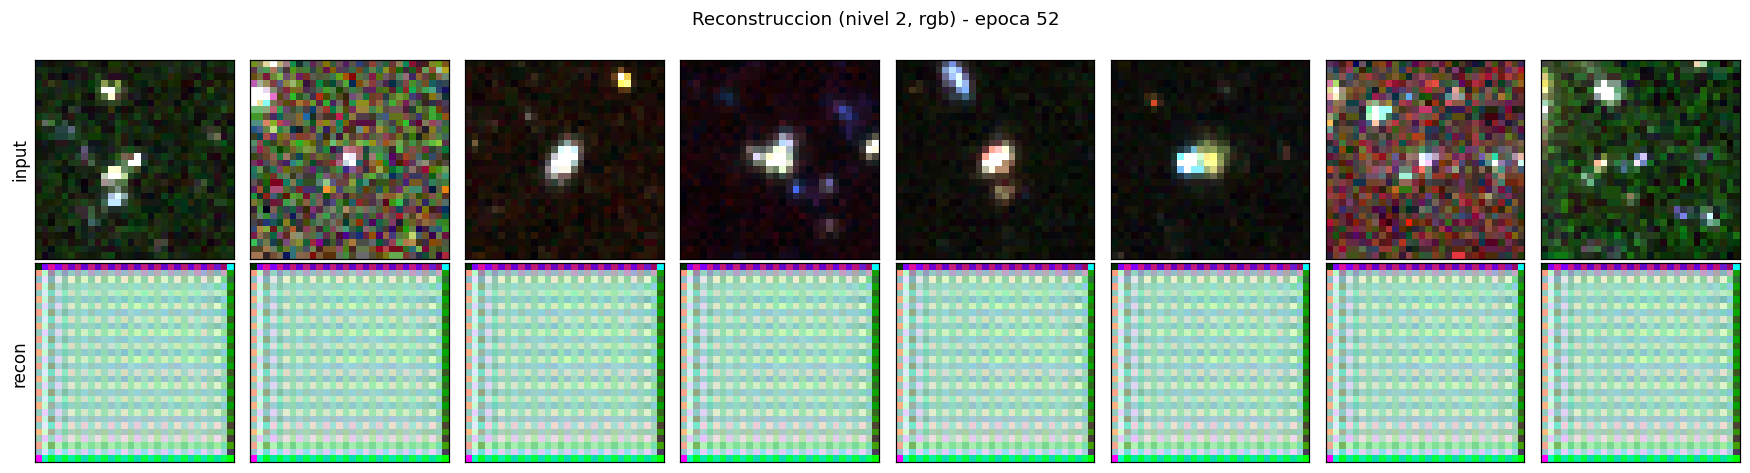

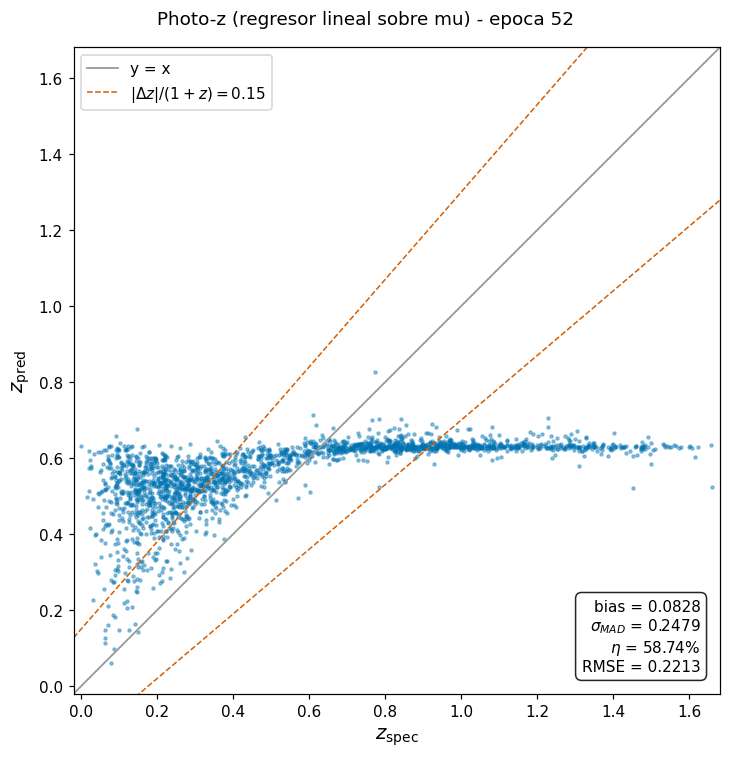

In [41]:
import glob
from IPython.display import Image, display

run_dirs = sorted(
    glob.glob(f"{DRIVE_OUT_DIR}/figures/vae*"),
    key=lambda p: int(p.rsplit("vae", 1)[-1]) if p.rsplit("vae", 1)[-1].isdigit() else -1,
)

if run_dirs:
    latest_run = run_dirs[-1]
    print(f"corrida: {latest_run}")

    recon_imgs = sorted(glob.glob(f"{latest_run}/recon_e*.png"))
    if recon_imgs:
        display(Image(filename=recon_imgs[-1]))
    else:
        print("sin figuras de reconstrucción todavía")

    photoz_imgs = sorted(glob.glob(f"{latest_run}/photoz_e*.png"))
    if photoz_imgs:
        display(Image(filename=photoz_imgs[-1]))
    else:
        print("sin figuras de photo-z todavía")
else:
    print("todavía no hay corridas en", DRIVE_OUT_DIR)


## Siguientes pasos

- Todo lo relevante (`vae_metrics{N}.csv`, `vae_summary{N}.json`, `figures/vae{N}/`,
  `checkpoints/vae_best{N}.pt`, `vae{N}.input`) ya quedó en
  `DRIVE_OUT_DIR` gracias al symlink — no se pierde al cerrar el runtime.
- `vae_summary{N}.json` incluye `z_mean`/`z_std` (estadísticas de train usadas
  para normalizar el redshift) y las métricas finales de photo-z
  (`final_pz_bias`, `final_pz_sigma_mad`, `final_pz_eta`, `final_pz_rmse`).
- Para compartirlo con el equipo vía git: copia (o descarga) esos archivos desde
  Drive a tu clon local de `file_out_data/` y comitea desde ahí — evita comitear
  directo desde el runtime efímero de Colab.